## Step 1 — Dataset path set



In [ ]:
import os
from pathlib import Path

try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# ========= Output location (Colab-friendly) =========
# Colab এ সাধারণত session reset হলে /content-এর সব মুছে যায়।
# তাই চাইলে Drive-এ output save করতে পারবেন।
SAVE_OUTPUTS_TO_DRIVE = True  # <-- দরকার হলে False করুন

if IN_COLAB and SAVE_OUTPUTS_TO_DRIVE:
    drive.mount('/content/drive', force_remount=True)
    OUTPUT_ROOT = Path("/content/drive/MyDrive/processed_outputs")
else:
    OUTPUT_ROOT = Path("processed_outputs")

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Make matplotlib cache writable (avoids warnings/slow imports)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_ROOT / "mpl_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

# ========= Dataset path =========
# Drive-এ dataset থাকলে এখানে path দিন
if IN_COLAB:
    DATA_PATH = "/content/drive/MyDrive/All Dataset"
else:
    DATA_PATH = str(Path("All Dataset"))

data_dir = Path(DATA_PATH)
print("DATA_PATH =", DATA_PATH)
print("OUTPUT_ROOT =", OUTPUT_ROOT)
assert data_dir.exists(), f"Dataset folder not found: {DATA_PATH}"


Mounted at /content/drive
DATA_PATH = /content/drive/MyDrive/All Dataset
OUTPUT_ROOT = /content/drive/MyDrive/processed_outputs


## Step 2 — Config


In [ ]:
from pathlib import Path

# ---------- Image shape ----------
# Resize target
IMG_SIZE = (64, 64)

# 'grayscale' অথবা 'rgb'
COLOR_MODE = "rgb"

# ---------- Preprocessing options ----------
APPLY_CLAHE = True          # contrast improve (cv2 থাকলে)
DENOISE_MEDIAN = True       # median blur
NORMALIZE_0_1 = True        # 0..255 -> 0..1
STANDARDIZE = False         # (x-mean)/std (NORMALIZE_0_1 এর পরে)

# ---------- Split options ----------
SEED = 42
TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

BATCH_SIZE = 32

# ---------- Data augmentation (train only) ----------
USE_AUGMENTATION = True
AUG_FLIP = True
AUG_ROTATION = 0.05
AUG_ZOOM = 0.05
AUG_CONTRAST = 0.10

# augmentation এর পরে value 0..1 range-এর বাইরে চলে যেতে পারে (RandomContrast/Rotation এর জন্য)
CLIP_AFTER_AUG = True

# ---------- Leakage-safe split ----------
# Group split = একই patient/case/series-এর multiple slice থাকলে train/test leak আটকাবে
GROUP_SPLIT = True
GROUP_KEY_MODE = "before_slice_or_first_token"  # internal rule

# ---------- Class imbalance handling ----------
# Option A (recommended): use class_weights in model.fit(...)
USE_CLASS_WEIGHTS = True

# Option B: balanced sampling dataset (needs steps_per_epoch)
USE_BALANCED_SAMPLING = False
STEPS_PER_EPOCH = None  # e.g. len(train)//BATCH_SIZE

# ---------- Labeling (optional) ----------
# আপনার dataset-এর অনেক ফাইলে label string নেই, তাই default 'none'
# Supervised classification করতে চাইলে label source লাগবে (CSV/filename rules)
LABEL_MODE = "filename"   # 'none' or 'filename'

# filename-এ label না থাকলে এই label assign হবে (আপনার request অনুযায়ী)
DEFAULT_UNKNOWN_LABEL = "Normal"

# filename rule (যদি LABEL_MODE='filename')
MAP_NI_TO_NORMAL = True
ALLOWED_LABELS = ["Benign", "Malignant", "Normal"]

# ---------- Outputs ----------
OUT_DIR = OUTPUT_ROOT
OUT_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_DIR = OUT_DIR / "splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

print("SPLIT_DIR =", SPLIT_DIR)


SPLIT_DIR = /content/drive/MyDrive/processed_outputs/splits


## Step 3 — Collect ALL image paths


In [ ]:
import os
from collections import Counter

VALID_EXTS = {".jpg", ".jpeg", ".png"}

image_paths: list[str] = []
ext_counter = Counter()

for entry in os.scandir(data_dir):
    if not entry.is_file():
        continue
    ext = Path(entry.name).suffix.lower()
    if ext not in VALID_EXTS:
        continue
    image_paths.append(entry.path)
    ext_counter[ext] += 1

# stable order for reproducibility
image_paths.sort()

print("Total images:", len(image_paths))
print("Extensions:", ext_counter)
print("Sample:")
for p in image_paths[:5]:
    print(" -", Path(p).name)


Total images: 53853
Extensions: Counter({'.jpg': 49144, '.png': 4709})
Sample:
 - 0_Benign (1).JPG
 - 10000_0832_NI000_slice000_png_jpg.rf.be12cfb0e205d5506d0d794ef2763f39.jpg
 - 10001_0832_NI001_slice000_png_jpg.rf.63138c881799fdfa6f6bf55a4fed1238.jpg
 - 10002_0832_NI002_slice000_png_jpg.rf.d7816d6219cdce88c597e4db116dd4fe.jpg
 - 10003_0832_NI002_slice001_png_jpg.rf.7715ddf8da81007bb21434daf7215e4a.jpg


## Step 4 — Optional label extraction


In [ ]:
from collections import Counter

def extract_label_from_filename(filename: str) -> str:
    low = filename.lower()
    if "malignant" in low:
        return "Malignant"
    if "benign" in low:
        return "Benign"
    if "normal" in low:
        return "Normal"
    if MAP_NI_TO_NORMAL and "_ni" in low:
        return "Normal"
    return DEFAULT_UNKNOWN_LABEL

labels: list[str] = [DEFAULT_UNKNOWN_LABEL] * len(image_paths)

if LABEL_MODE == "filename":
    for i, p in enumerate(image_paths):
        lab = extract_label_from_filename(Path(p).name)
        if lab in ALLOWED_LABELS:
            labels[i] = lab

lab_counter = Counter(labels)
unlabeled_count = sum(1 for x in labels if (x is None) or (x == ""))

print("LABEL_MODE =", LABEL_MODE)
print("Labeled counts:", lab_counter)
print("Unlabeled:", unlabeled_count)


LABEL_MODE = filename
Labeled counts: Counter({'Normal': 43044, 'Malignant': 7221, 'Benign': 3588})
Unlabeled: 0


## Step 5 — Train/Val/Test split (ALL images)


In [ ]:
import csv
import numpy as np
import re
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split

idx_all = np.arange(len(image_paths))

rf_re = re.compile(r"\.rf\.[0-9a-f]+$", re.I)
paren_re = re.compile(r"\s*\(\d+\)$")

def group_key_from_filename(filename: str) -> str:
    # 1) remove extension
    stem = Path(filename).stem
    # 2) remove roboflow hash suffix
    stem = rf_re.sub("", stem)
    # 3) remove trailing (n)
    stem = paren_re.sub("", stem)

    low = stem.lower()
    # 4) common medical naming: ..._slice###...
    if "_slice" in low:
        return stem[: low.index("_slice")]

    # 5) fallback: numeric_*.jpg -> group by first token
    parts = stem.split("_")
    if len(parts) >= 2 and parts[0].isdigit():
        return parts[0]

    return stem

y = np.array(labels)

if GROUP_SPLIT:
    group_to_indices: dict[str, list[int]] = defaultdict(list)
    for i, p in enumerate(image_paths):
        group_to_indices[group_key_from_filename(Path(p).name)].append(i)

    groups = np.array(list(group_to_indices.keys()), dtype=object)

    # group label = majority label inside the group
    group_labels = []
    mixed_groups = 0
    for g in groups:
        labs = [labels[i] for i in group_to_indices[g]]
        c = Counter(labs)
        if len(c) > 1:
            mixed_groups += 1
        group_labels.append(c.most_common(1)[0][0])
    group_labels = np.array(group_labels)

    print("Groups:", len(groups), "(mixed-label groups:", mixed_groups, ")")

    # stratified split on groups (leakage-safe)
    try:
        train_g, temp_g = train_test_split(
            groups,
            test_size=(1.0 - TRAIN_RATIO),
            random_state=SEED,
            stratify=group_labels,
        )
        val_portion_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
        temp_labels = np.array([Counter([labels[i] for i in group_to_indices[g]]).most_common(1)[0][0] for g in temp_g])
        val_g, test_g = train_test_split(
            temp_g,
            test_size=(1.0 - val_portion_of_temp),
            random_state=SEED,
            stratify=temp_labels,
        )
    except ValueError as e:
        print("Warning: stratified group split failed -> fallback to non-stratified.")
        print("Reason:", e)
        train_g, temp_g = train_test_split(
            groups,
            test_size=(1.0 - TRAIN_RATIO),
            random_state=SEED,
            shuffle=True,
        )
        val_portion_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
        val_g, test_g = train_test_split(
            temp_g,
            test_size=(1.0 - val_portion_of_temp),
            random_state=SEED,
            shuffle=True,
        )

    train_idx = np.array([i for g in train_g for i in group_to_indices[g]], dtype=np.int64)
    val_idx = np.array([i for g in val_g for i in group_to_indices[g]], dtype=np.int64)
    test_idx = np.array([i for g in test_g for i in group_to_indices[g]], dtype=np.int64)

    # leakage check: no group overlaps
    train_set = set(train_g.tolist())
    val_set = set(val_g.tolist())
    test_set = set(test_g.tolist())
    print("Leakage check (group overlap):")
    print("  train∩val =", len(train_set & val_set))
    print("  train∩test=", len(train_set & test_set))
    print("  val∩test =", len(val_set & test_set))
else:
    # image-level stratified split
    train_idx, temp_idx = train_test_split(
        idx_all,
        test_size=(1.0 - TRAIN_RATIO),
        random_state=SEED,
        stratify=y,
    )
    val_portion_of_temp = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=(1.0 - val_portion_of_temp),
        random_state=SEED,
        stratify=y[temp_idx],
    )

class_names = sorted(list(set(labels)))
label_to_id = {name: i for i, name in enumerate(class_names)}
print("class_names:", class_names)

def _count_labels(idxs: np.ndarray) -> dict[str, int]:
    return dict(Counter([labels[int(i)] for i in idxs]))

print("Label dist (train):", _count_labels(train_idx))
print("Label dist (val):  ", _count_labels(val_idx))
print("Label dist (test): ", _count_labels(test_idx))

def write_split_csv(name: str, idxs: np.ndarray) -> Path:
    out_path = SPLIT_DIR / f"{name}.csv"
    with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["path", "label", "label_id"])
        for i in idxs:
            lab = labels[int(i)]
            w.writerow([image_paths[int(i)], lab, label_to_id[lab]])
    return out_path

p_train = write_split_csv("train", train_idx)
p_val = write_split_csv("val", val_idx)
p_test = write_split_csv("test", test_idx)

print("Total:", len(idx_all))
print("Train:", len(train_idx), "->", p_train)
print("Val:  ", len(val_idx), "->", p_val)
print("Test: ", len(test_idx), "->", p_test)


Groups: 53852 (mixed-label groups: 0 )
Leakage check (group overlap):
  train∩val = 0
  train∩test= 0
  val∩test = 0
class_names: ['Benign', 'Malignant', 'Normal']
Label dist (train): {'Normal': 34435, 'Malignant': 5777, 'Benign': 2870}
Label dist (val):   {'Normal': 4304, 'Benign': 359, 'Malignant': 722}
Label dist (test):  {'Normal': 4305, 'Malignant': 722, 'Benign': 359}
Total: 53853
Train: 43082 -> /content/drive/MyDrive/processed_outputs/splits/train.csv
Val:   5385 -> /content/drive/MyDrive/processed_outputs/splits/val.csv
Test:  5386 -> /content/drive/MyDrive/processed_outputs/splits/test.csv


## Step 6 — Preprocessing function


In [ ]:
import numpy as np

try:
    import cv2  # type: ignore
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

def preprocess_image_np(path: str) -> np.ndarray:
    if not HAS_CV2:
        raise RuntimeError("OpenCV (cv2) পাওয়া যায়নি। local environment-এ `opencv-python` install করুন।")

    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        raise ValueError(f"Failed to read image: {path}")

    if COLOR_MODE == "grayscale":
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif COLOR_MODE == "rgb":
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        if img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2BGR)
    else:
        raise ValueError(f"Unknown COLOR_MODE: {COLOR_MODE}")

    if APPLY_CLAHE:
        if COLOR_MODE == "grayscale":
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            img = clahe.apply(img)
        else:
            lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
            l, a, b = cv2.split(lab)
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            l2 = clahe.apply(l)
            img = cv2.cvtColor(cv2.merge((l2, a, b)), cv2.COLOR_LAB2BGR)

    if DENOISE_MEDIAN:
        img = cv2.medianBlur(img, 3)

    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]), interpolation=cv2.INTER_AREA)

    x = img.astype(np.float32)
    if COLOR_MODE == "grayscale":
        x = np.expand_dims(x, axis=-1)
    else:
        x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

    if NORMALIZE_0_1:
        x = x / 255.0
    if STANDARDIZE:
        mean = float(x.mean())
        std = float(x.std() + 1e-6)
        x = (x - mean) / std

    return x

# quick test
sample_x = preprocess_image_np(image_paths[0])
print("sample:", sample_x.shape, sample_x.dtype, float(sample_x.min()), float(sample_x.max()))


sample: (64, 64, 3) float32 0.03921568766236305 1.0


## Step 7 — Split CSV, Augmentation


In [ ]:
import csv
import numpy as np
import tensorflow as tf

H, W = IMG_SIZE
C = 1 if COLOR_MODE == "grayscale" else 3

def read_split_csv(path: Path) -> tuple[list[str], list[int], list[str]]:
    paths: list[str] = []
    lab_ids: list[int] = []
    labs: list[str] = []
    with path.open("r", newline="", encoding="utf-8") as f:
        r = csv.DictReader(f)
        for row in r:
            paths.append(row["path"])
            lab_ids.append(int(row["label_id"]))
            labs.append(row.get("label", "") or "")
    return paths, lab_ids, labs

train_paths, train_lab_ids, train_labs = read_split_csv(p_train)
val_paths, val_lab_ids, val_labs = read_split_csv(p_val)
test_paths, test_lab_ids, test_labs = read_split_csv(p_test)

# --------- Class imbalance stats + weights (Option A) ---------
num_classes = int(max(train_lab_ids)) + 1
train_counts = np.bincount(np.array(train_lab_ids, dtype=np.int32), minlength=num_classes)
print("Train class counts:", train_counts.tolist())

class_weights = None
if USE_CLASS_WEIGHTS:
    total = float(train_counts.sum())
    class_weights = {i: (total / (num_classes * float(c))) for i, c in enumerate(train_counts) if c > 0}
    print("class_weights (use in model.fit):", class_weights)

def _py_preprocess(path_bytes: bytes) -> np.ndarray:
    return preprocess_image_np(path_bytes.decode("utf-8"))

def tf_preprocess(path: tf.Tensor) -> tf.Tensor:
    x = tf.numpy_function(_py_preprocess, [path], tf.float32)
    x.set_shape([H, W, C])
    return x

# --------- Data augmentation (train only) ---------
augment = None
if USE_AUGMENTATION:
    layers = []
    if AUG_FLIP:
        layers.append(tf.keras.layers.RandomFlip("horizontal"))
    if AUG_ROTATION and AUG_ROTATION > 0:
        layers.append(tf.keras.layers.RandomRotation(AUG_ROTATION))
    if AUG_ZOOM and AUG_ZOOM > 0:
        layers.append(tf.keras.layers.RandomZoom(AUG_ZOOM))
    if AUG_CONTRAST and AUG_CONTRAST > 0:
        layers.append(tf.keras.layers.RandomContrast(AUG_CONTRAST))
    augment = tf.keras.Sequential(layers, name="augmentation")

def make_ds(paths: list[str], lab_ids: list[int], training: bool) -> tf.data.Dataset:
    ds = tf.data.Dataset.from_tensor_slices((tf.constant(paths), tf.constant(lab_ids, dtype=tf.int32)))
    if training:
        ds = ds.shuffle(buffer_size=min(2000, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (tf_preprocess(p), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training and (augment is not None):
        def _aug(x, y):
            x = augment(x, training=True)
            if CLIP_AFTER_AUG:
                x = tf.clip_by_value(x, 0.0, 1.0)
            return x, y
        ds = ds.map(_aug, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_ds(train_paths, train_lab_ids, training=True)
val_ds = make_ds(val_paths, val_lab_ids, training=False)
test_ds = make_ds(test_paths, test_lab_ids, training=False)

# --------- Balanced sampling dataset (Option B) ---------
balanced_train_ds = None
if USE_BALANCED_SAMPLING:
    per_class = {i: [] for i in range(num_classes)}
    for p, y in zip(train_paths, train_lab_ids):
        per_class[int(y)].append(p)

    datasets = []
    for i in range(num_classes):
        paths_i = per_class[i]
        if not paths_i:
            continue
        ds_i = tf.data.Dataset.from_tensor_slices((tf.constant(paths_i), tf.constant([i] * len(paths_i), dtype=tf.int32)))
        ds_i = ds_i.shuffle(buffer_size=min(2000, len(paths_i)), seed=SEED, reshuffle_each_iteration=True)
        ds_i = ds_i.repeat()
        ds_i = ds_i.map(lambda p, y: (tf_preprocess(p), y), num_parallel_calls=tf.data.AUTOTUNE)
        if augment is not None:
            def _aug_i(x, y):
                x = augment(x, training=True)
                if CLIP_AFTER_AUG:
                    x = tf.clip_by_value(x, 0.0, 1.0)
                return x, y
            ds_i = ds_i.map(_aug_i, num_parallel_calls=tf.data.AUTOTUNE)
        datasets.append(ds_i)

    # equal sampling across available classes
    balanced_train_ds = tf.data.Dataset.sample_from_datasets(datasets)
    balanced_train_ds = balanced_train_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    if STEPS_PER_EPOCH is None:
        STEPS_PER_EPOCH = max(1, len(train_paths) // BATCH_SIZE)
    print("balanced_train_ds ready. Use model.fit(balanced_train_ds, steps_per_epoch=STEPS_PER_EPOCH, ...)")

print("train_ds:", train_ds)
print("val_ds:", val_ds)
print("test_ds:", test_ds)


Train class counts: [2870, 5777, 34435]
class_weights (use in model.fit): {0: 5.003716608594657, 1: 2.4858346315850213, 2: 0.41703692948066406}
train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
test_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


## Step 8 — Visualizing Preprocess and Augmentation


x_batch: (32, 64, 64, 3) <dtype: 'float32'>
y_batch: (32,) <dtype: 'int32'>


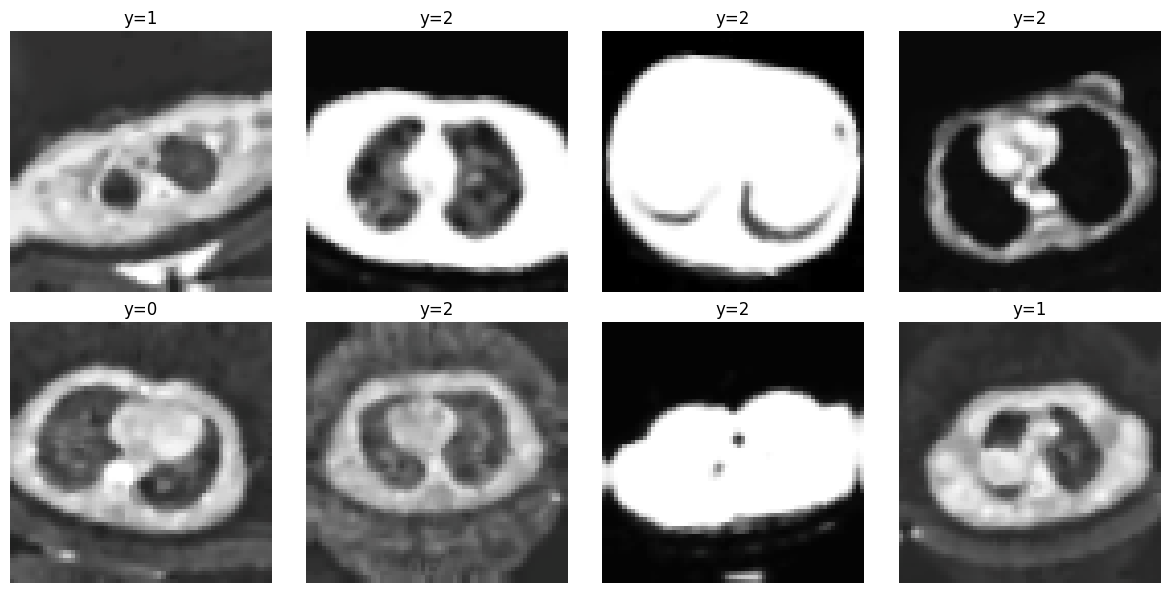

In [ ]:
import matplotlib.pyplot as plt

x_batch, y_batch = next(iter(train_ds))
print("x_batch:", x_batch.shape, x_batch.dtype)
print("y_batch:", y_batch.shape, y_batch.dtype)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()
for i in range(8):
    ax = axes[i]
    ax.axis('off')
    x = x_batch[i].numpy()
    # safety: matplotlib এর warning avoid করতে 0..1 range নিশ্চিত করা
    x = x.clip(0.0, 1.0)
    ax.set_title(f"y={int(y_batch[i])}")
    if x.shape[-1] == 1:
        ax.imshow(x[..., 0], cmap='gray')
    else:
        ax.imshow(x)
plt.tight_layout()
plt.show()


## Step 9 — Models (CNN+ViT / CNN+EfficientNetB3 / CNN+XGBoost)


Output Folder Structure

In [ ]:
import os
import time
import json
import numpy as np
import tensorflow as tf

from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

PLOTS_DIR = OUT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_PATH = OUT_DIR / "metrics.json"

MODELS_DIR = OUT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42):
    import random
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)

def savefig(name: str):
    out = PLOTS_DIR / name
    plt.savefig(out, dpi=200, bbox_inches="tight")
    print("saved:", out)


Training Configaration

In [ ]:
# Training config
EPOCHS = 2
LR = 1e-3
FREEZE_EFFICIENTNET = True

# Fast run (debug) — enable করলে কম sample নিয়ে run হবে
FAST_DEV_RUN = False
FAST_TRAIN_SAMPLES = 2000
FAST_VAL_SAMPLES = 500
FAST_TEST_SAMPLES = 500

def maybe_take(ds: tf.data.Dataset, n: int) -> tf.data.Dataset:
    if not FAST_DEV_RUN:
        return ds
    return ds.unbatch().take(n).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds_run = maybe_take(train_ds, FAST_TRAIN_SAMPLES)
val_ds_run = maybe_take(val_ds, FAST_VAL_SAMPLES)
test_ds_run = maybe_take(test_ds, FAST_TEST_SAMPLES)

print("FAST_DEV_RUN =", FAST_DEV_RUN)


FAST_DEV_RUN = False


Model Backbone

In [ ]:
def build_cnn_backbone(input_shape: tuple[int,int,int]):
    inp = tf.keras.Input(shape=input_shape)
    x = inp
    for filters in [32, 64, 128]:
        x = tf.keras.layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.ReLU()(x)
        x = tf.keras.layers.MaxPool2D()(x)
    return tf.keras.Model(inp, x, name="cnn_backbone")

def transformer_block(x, num_heads: int, mlp_dim: int, dropout: float = 0.1):
    y = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    y = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=int(x.shape[-1]))(y, y)
    y = tf.keras.layers.Dropout(dropout)(y)
    x = tf.keras.layers.Add()([x, y])

    y = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x)
    y = tf.keras.layers.Dense(mlp_dim, activation=tf.nn.gelu)(y)
    y = tf.keras.layers.Dropout(dropout)(y)
    y = tf.keras.layers.Dense(int(x.shape[-1]))(y)
    y = tf.keras.layers.Dropout(dropout)(y)
    return tf.keras.layers.Add()([x, y])

def build_cnn_vit_hybrid(num_classes: int):
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1 if COLOR_MODE=="grayscale" else 3)
    inp = tf.keras.Input(shape=input_shape)
    cnn = build_cnn_backbone(input_shape)
    feat = cnn(inp)

    cnn_vec = tf.keras.layers.GlobalAveragePooling2D(name="cnn_gap")(feat)
    cnn_vec = tf.keras.layers.Dense(128, activation="relu")(cnn_vec)

    tokens = tf.keras.layers.Reshape((-1, int(feat.shape[-1])))(feat)
    num_tokens = int(tokens.shape[1])
    dim = int(tokens.shape[-1])
    pos = tf.keras.layers.Embedding(input_dim=num_tokens, output_dim=dim)
    positions = tf.range(start=0, limit=num_tokens, delta=1)
    tok = tokens + pos(positions)
    for _ in range(4):
        tok = transformer_block(tok, num_heads=4, mlp_dim=dim*2, dropout=0.1)
    vit_vec = tf.keras.layers.LayerNormalization(epsilon=1e-6)(tok)
    vit_vec = tf.keras.layers.GlobalAveragePooling1D(name="vit_gap")(vit_vec)
    vit_vec = tf.keras.layers.Dense(128, activation="relu")(vit_vec)

    x = tf.keras.layers.Concatenate()([cnn_vec, vit_vec])
    x = tf.keras.layers.Dropout(0.2)(x)
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="cnn_vit")

def build_cnn_efficientnetb3(num_classes: int):
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1 if COLOR_MODE=="grayscale" else 3)
    if input_shape[-1] != 3:
        raise ValueError("EfficientNet requires RGB (set COLOR_MODE=\"rgb\")")

    inp = tf.keras.Input(shape=input_shape)
    try:
        base = tf.keras.applications.EfficientNetB3(include_top=False, weights="imagenet", input_shape=input_shape, pooling="avg")
        x_eff = tf.keras.applications.efficientnet.preprocess_input(inp)
        eff_feat = base(x_eff)
    except Exception as e:
        print("EfficientNet imagenet weights not available; using weights=None. Reason:", e)
        base = tf.keras.applications.EfficientNetB3(include_top=False, weights=None, input_shape=input_shape, pooling="avg")
        eff_feat = base(inp)

    base.trainable = not FREEZE_EFFICIENTNET

    cnn = build_cnn_backbone(input_shape)
    cnn_feat = cnn(inp)
    cnn_vec = tf.keras.layers.GlobalAveragePooling2D()(cnn_feat)
    cnn_vec = tf.keras.layers.Dense(128, activation="relu")(cnn_vec)

    x = tf.keras.layers.Concatenate()([eff_feat, cnn_vec])
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    return tf.keras.Model(inp, out, name="cnn_effnetb3")


Confusion Matrix, ROC Curves, Compare Matrix, Compare Time

In [ ]:
def evaluate_keras_model(model_name: str, model: tf.keras.Model, test_ds: tf.data.Dataset, class_names: list[str]):
    y_true = []
    y_prob = []
    for x, y in test_ds:
        p = model.predict(x, verbose=0)
        y_true.append(y.numpy())
        y_prob.append(p)
    y_true = np.concatenate(y_true, axis=0).astype(int)
    y_prob = np.concatenate(y_prob, axis=0)
    y_pred = y_prob.argmax(axis=1)

    acc = float(accuracy_score(y_true, y_pred))
    f1m = float(f1_score(y_true, y_pred, average="macro"))
    f1w = float(f1_score(y_true, y_pred, average="weighted"))
    pm = float(precision_score(y_true, y_pred, average="macro", zero_division=0))
    rm = float(recall_score(y_true, y_pred, average="macro", zero_division=0))

    aucm = None
    try:
        aucm = float(roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro"))
    except Exception as e:
        print("AUC skipped:", e)

    print("\n==", model_name, "==")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Pred")
    plt.ylabel("True")
    savefig(f"cm_{model_name}.png")
    plt.close()

    # ROC curves (One-vs-Rest)
    try:
        from sklearn.preprocessing import label_binarize
        from sklearn.metrics import roc_curve, auc
        y_bin = label_binarize(y_true, classes=list(range(len(class_names))))
        plt.figure(figsize=(6,5))
        for i, cls in enumerate(class_names):
            fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
            plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
        plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
        plt.xlabel("FPR")
        plt.ylabel("TPR")
        plt.title(f"ROC (OVR) — {model_name}")
        plt.legend(fontsize=8)
        savefig(f"roc_{model_name}.png")
        plt.close()
    except Exception as e:
        print("ROC plot skipped:", e)

    return {
        "name": model_name,
        "accuracy": acc,
        "f1_macro": f1m,
        "f1_weighted": f1w,
        "precision_macro": pm,
        "recall_macro": rm,
        "auc_ovr_macro": aucm,
    }

def train_keras(model: tf.keras.Model, model_name: str):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(LR),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    callbacks = [tf.keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True)]
    start = time.time()
    hist = model.fit(
        balanced_train_ds if USE_BALANCED_SAMPLING else train_ds_run,
        validation_data=val_ds_run,
        epochs=EPOCHS,
        class_weight=class_weights if USE_CLASS_WEIGHTS and (not USE_BALANCED_SAMPLING) else None,
        steps_per_epoch=STEPS_PER_EPOCH if USE_BALANCED_SAMPLING else None,
        callbacks=callbacks,
        verbose=1,
    )
    seconds = time.time() - start

    plt.figure(figsize=(8,3))
    plt.subplot(1,2,1)
    plt.plot(hist.history.get("loss", []), label="train")
    plt.plot(hist.history.get("val_loss", []), label="val")
    plt.title(f"Loss — {model_name}")
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(hist.history.get("accuracy", []), label="train")
    plt.plot(hist.history.get("val_accuracy", []), label="val")
    plt.title(f"Accuracy — {model_name}")
    plt.legend()
    savefig(f"curves_{model_name}.png")
    plt.close()

    # save trained model (so you can reuse in Step 10)
    safe_name = model_name.replace(" ", "_").replace("/", "_")
    model_path = MODELS_DIR / f"{safe_name}.keras"
    model.save(model_path)
    print("saved model:", model_path)

    return hist, float(seconds)


CNN+ViT

In [ ]:
results = []

# 1) CNN + ViT (main focus)
model_vit = build_cnn_vit_hybrid(num_classes=len(class_names))
model_vit.summary()
_, sec_vit = train_keras(model_vit, "CNN_ViT")
m_vit = evaluate_keras_model("CNN_ViT", model_vit, test_ds_run, class_names)
m_vit["seconds_train"] = sec_vit
results.append(m_vit)


Model: "cnn_vit"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_backbone        │ (None, 8, 8, 128) │     93,920 │ input_layer_7[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 64, 128)   │          0 │ cnn_backbone[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_27 (Add)        │ (None, 64, 128)   │          0 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_27[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_52          │ (None, 64, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_28 (Add)        │ (None, 64, 128)   │          0 │ add_27[0][0],     │
│                     │                   │            │ dropout_52[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_28[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_34 (Dense)    │ (None, 64, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_53          │ (None, 64, 256)   │          0 │ dense_34[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_35 (Dense)    │ (None, 64, 128)   │     32,896 │ dropout_53[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_54          │ (None, 64, 128)   │          0 │ dense_35[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_29 (Add)        │ (None, 64, 128)   │          0 │ add_28[0][0],     │
│                     │                   │            │ dropout_54[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 128)   │        256 │ add_29[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 128)   │    263,808 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 64, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_30 (Add)        │ (None, 64, 128)   │          0 │ add_29[0][0],     │
│                     │                   │            │ dropout_56[0][0]

 Total params: 1,448,931 (5.53 MB)

 Trainable params: 1,448,483 (5.53 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 6149s 5s/step - accuracy: 0.7634 - loss: 0.6635 - val_accuracy: 0.8563 - val_loss: 0.3571
Epoch 2/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 1935s 1s/step - accuracy: 0.8171 - loss: 0.5136 - val_accuracy: 0.8520 - val_loss: 0.2782
saved: /content/drive/MyDrive/processed_outputs/plots/curves_CNN_ViT.png
saved model: /content/drive/MyDrive/processed_outputs/models/CNN_ViT.keras

== CNN_ViT ==
              precision    recall  f1-score   support

      Benign       0.33      0.79      0.46       359
   Malignant       0.78      0.92      0.84       722
      Normal       1.00      0.85      0.92      4305

    accuracy                           0.86      5386
   macro avg       0.70      0.85      0.74      5386
weighted avg       0.92      0.86      0.88      5386

saved: /content/drive/MyDrive/processed_outputs/plots/cm_CNN_ViT.png
saved: /content/drive/MyDrive/processed_outputs/plots/roc_CNN_ViT.png


CNN+VIT+XGBOOST

In [ ]:
# 4) CNN + ViT + XGBoost (CNN+ViT embeddings -> XGBoost)
# Note: Run Step 9 (CNN_ViT) first so `model_vit`, `train_ds_run`, `test_ds_run`, and `class_names` exist.

import time
import numpy as np
from pathlib import Path

import tensorflow as tf
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

print("\n[Hybrid] CNN + ViT + XGBoost started")
start_all = time.time()

# ---- safety fallbacks (if you run this cell standalone) ----
print("[1/7] Setup + sanity checks")
if "results" not in globals():
    results = []
    print("- `results` not found -> created new list")
else:
    print(f"- `results` found -> current length: {len(results)}")

if "savefig" not in globals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    PLOTS_DIR = Path("processed") / "plots"
    PLOTS_DIR.mkdir(parents=True, exist_ok=True)
    def savefig(name: str):
        out = PLOTS_DIR / name
        plt.savefig(out, dpi=200, bbox_inches="tight")
        print("saved:", out)
    print("- `savefig` not found -> defined a local savefig()")
else:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("- `savefig` found")

# ---- load trained CNN+ViT model if needed ----
print("[2/7] Load CNN+ViT model (`model_vit`)")
if "model_vit" not in globals():
    model_path = Path("processed") / "models" / "cnn_vit.keras"
    print("- `model_vit` not in globals -> trying load:", model_path)
    if model_path.exists():
        model_vit = tf.keras.models.load_model(model_path)
        print("- Loaded model:", model_path)
    else:
        raise RuntimeError(
            "No trained CNN+ViT model found. Run Step 9 to train `model_vit`, or save it at processed/models/cnn_vit.keras"
        )
else:
    print("- Using existing `model_vit` from memory")

# ---- feature extractor: concatenate named CNN/VIT pooling vectors ----
print("[3/7] Build feature model (cnn_gap + vit_gap)")
try:
    cnn_gap = model_vit.get_layer("cnn_gap").output
    vit_gap = model_vit.get_layer("vit_gap").output
except Exception as e:
    raise RuntimeError(
        "Expected layers named 'cnn_gap' and 'vit_gap' in model_vit.\n"
        "Make sure you trained the provided CNN_ViT model definition (Step 9)."
    ) from e

hyb_feat = tf.keras.layers.Concatenate(name="cnn_vit_concat_feats")([cnn_gap, vit_gap])
feat_model_vit = tf.keras.Model(model_vit.input, hyb_feat, name="cnn_vit_feature_model")
print("- Feature dim:", int(feat_model_vit.output_shape[-1]))

# ---- extract embeddings from datasets ----
print("[4/7] Extract hybrid features from train/test datasets")

def extract_hybrid_feats(ds: tf.data.Dataset, tag: str):
    t0 = time.time()
    feats, ys = [], []
    n_batches = 0
    for n_batches, (x, y) in enumerate(ds, start=1):
        feats.append(feat_model_vit.predict(x, verbose=0))
        ys.append(y.numpy())
        if n_batches % 25 == 0:
            print(f"  - {tag}: processed {n_batches} batches...")
    if n_batches == 0:
        raise RuntimeError(f"Dataset `{tag}` is empty")
    X = np.concatenate(feats, axis=0).astype(np.float32)
    y = np.concatenate(ys, axis=0).astype(int)
    print(f"  - {tag}: X={X.shape}, y={y.shape} (time={time.time()-t0:.1f}s)")
    return X, y

Xtr_h, ytr_h = extract_hybrid_feats(train_ds_run, "train")
Xte_h, yte_h = extract_hybrid_feats(test_ds_run, "test")

# ---- train XGBoost (or fallback) ----
print("[5/7] Train classifier (XGBoost -> fallback if not installed)")
model_name = "CNN_ViT_XGBoost"
prob = None

# align hyperparams with Step 9's CNN_XGBoost cell
xgb_params = dict(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    n_jobs=4,
)

t0 = time.time()
try:
    import xgboost as xgb  # type: ignore
    print("- Using: xgboost.XGBClassifier")
    xgb_clf = xgb.XGBClassifier(**xgb_params)
    xgb_clf.fit(Xtr_h, ytr_h)
    prob = xgb_clf.predict_proba(Xte_h)
except Exception as e:
    print("- xgboost not available -> using sklearn HistGradientBoostingClassifier fallback")
    print("  Reason:", e)
    model_name = "CNN_ViT_GBDT_Fallback"
    gbdt = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05)
    gbdt.fit(Xtr_h, ytr_h)
    prob = gbdt.predict_proba(Xte_h)

sec = float(time.time() - t0)
print(f"- Training+predict time: {sec:.2f}s")

# ---- evaluate + plots ----
print("[6/7] Evaluate + save plots")
pred = prob.argmax(axis=1)
acc = float(accuracy_score(yte_h, pred))
f1m = float(f1_score(yte_h, pred, average="macro"))
f1w = float(f1_score(yte_h, pred, average="weighted"))
pm = float(precision_score(yte_h, pred, average="macro", zero_division=0))
rm = float(recall_score(yte_h, pred, average="macro", zero_division=0))
aucm = None
try:
    aucm = float(roc_auc_score(yte_h, prob, multi_class="ovr", average="macro"))
except Exception as e:
    print("- AUC skipped:", e)

print("\n==", model_name, "==")
print(f"accuracy={acc:.4f} | f1_macro={f1m:.4f} | f1_weighted={f1w:.4f} | auc_ovr_macro={aucm}")
print(classification_report(yte_h, pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(yte_h, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix — {model_name}")
plt.xlabel("Pred")
plt.ylabel("True")
savefig(f"cm_{model_name}.png")
plt.close()

try:
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc

    yb = label_binarize(yte_h, classes=list(range(len(class_names))))
    plt.figure(figsize=(6,5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(yb[:, i], prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC (OVR) — {model_name}")
    plt.legend(fontsize=8)
    savefig(f"roc_{model_name}.png")
    plt.close()
except Exception as e:
    print("- ROC plot skipped:", e)

# ---- append to results ----
print("[7/7] Append metrics to `results`")
results.append({
    "name": model_name,
    "accuracy": acc,
    "f1_macro": f1m,
    "f1_weighted": f1w,
    "precision_macro": pm,
    "recall_macro": rm,
    "auc_ovr_macro": aucm,
    "seconds_train": sec,
})
print("- Added to results:", results[-1])
print(f"[Hybrid] Done in {time.time()-start_all:.1f}s\n")


[Hybrid] CNN + ViT + XGBoost started
[1/7] Setup + sanity checks
- `results` found -> current length: 1
- `savefig` found
[2/7] Load CNN+ViT model (`model_vit`)
- Using existing `model_vit` from memory
[3/7] Build feature model (cnn_gap + vit_gap)
- Feature dim: 256
[4/7] Extract hybrid features from train/test datasets
  - train: processed 25 batches...
  - train: processed 50 batches...
  - train: processed 75 batches...
  - train: processed 100 batches...
  - train: processed 125 batches...
  - train: processed 150 batches...
  - train: processed 175 batches...
  - train: processed 200 batches...
  - train: processed 225 batches...
  - train: processed 250 batches...
  - train: processed 275 batches...
  - train: processed 300 batches...
  - train: processed 325 batches...
  - train: processed 350 batches...
  - train: processed 375 batches...
  - train: processed 400 batches...
  - train: processed 425 batches...
  - train: processed 450 batches...
  - train: processed 475 batches

CNN+EfficientnetB3

In [ ]:
# 2) CNN + EfficientNetB3
if COLOR_MODE != "rgb":
    print("Skipping CNN+EfficientNetB3 because COLOR_MODE is not rgb")
else:
    model_eff = build_cnn_efficientnetb3(num_classes=len(class_names))
    model_eff.summary()
    _, sec_eff = train_keras(model_eff, "CNN_EffNetB3")
    m_eff = evaluate_keras_model("CNN_EffNetB3", model_eff, test_ds_run, class_names)
    m_eff["seconds_train"] = sec_eff
    results.append(m_eff)


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "cnn_effnetb3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_backbone        │ (None, 8, 8, 128) │     93,920 │ input_layer_9[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ cnn_backbone[0][… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 1536)      │ 10,783,535 │ input_layer_9[0]… │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 1664)      │          0 │ efficientnetb3[0… │
│ (Concatenate)       │                   │            │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_68          │ (None, 1664)      │          0 │ concatenate_4[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_45 (Dense)    │ (None, 3)         │      4,995 │ dropout_68[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 10,898,962 (41.58 MB)

 Trainable params: 114,979 (449.14 KB)

 Non-trainable params: 10,783,983 (41.14 MB)

Epoch 1/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 1252s 900ms/step - accuracy: 0.7596 - loss: 0.6729 - val_accuracy: 0.7837 - val_loss: 0.5135
Epoch 2/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 1234s 909ms/step - accuracy: 0.8352 - loss: 0.4468 - val_accuracy: 0.8602 - val_loss: 0.2313
saved: /content/drive/MyDrive/processed_outputs/plots/curves_CNN_EffNetB3.png
saved model: /content/drive/MyDrive/processed_outputs/models/CNN_EffNetB3.keras

== CNN_EffNetB3 ==
              precision    recall  f1-score   support

      Benign       0.35      0.80      0.49       359
   Malignant       0.78      0.98      0.87       722
      Normal       1.00      0.85      0.92      4305

    accuracy                           0.86      5386
   macro avg       0.71      0.88      0.76      5386
weighted avg       0.93      0.86      0.88      5386

saved: /content/drive/MyDrive/processed_outputs/plots/cm_CNN_EffNetB3.png
saved: /content/drive/MyDrive/processed_outputs/plots/roc_CNN_EffNetB3.png


CNN+XGBoost

In [ ]:
# 3) CNN + XGBoost (embedding -> XGBoost). If xgboost not installed, fallback to sklearn GBDT.
from sklearn.ensemble import HistGradientBoostingClassifier

def extract_embeddings(feature_model: tf.keras.Model, ds: tf.data.Dataset):
    feats = []
    ys = []
    for x, y in ds:
        f = feature_model.predict(x, verbose=0)
        feats.append(f)
        ys.append(y.numpy())
    return np.concatenate(feats, axis=0), np.concatenate(ys, axis=0).astype(int)

def build_cnn_embedder(num_classes: int):
    input_shape = (IMG_SIZE[0], IMG_SIZE[1], 1 if COLOR_MODE=="grayscale" else 3)
    inp = tf.keras.Input(shape=input_shape)
    cnn = build_cnn_backbone(input_shape)
    feat = cnn(inp)
    emb = tf.keras.layers.GlobalAveragePooling2D()(feat)
    x = tf.keras.layers.Dense(256, activation="relu")(emb)
    out = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    clf = tf.keras.Model(inp, out, name="cnn_embed_clf")
    feat_model = tf.keras.Model(inp, x, name="cnn_embedding_model")
    return clf, feat_model

clf_embed, feat_model = build_cnn_embedder(num_classes=len(class_names))
_, sec_embed = train_keras(clf_embed, "CNN_Embed")

Xtr, ytr = extract_embeddings(feat_model, train_ds_run)
Xte, yte = extract_embeddings(feat_model, test_ds_run)
print("embeddings:", Xtr.shape, Xte.shape)

model_name = "CNN_XGBoost"
prob = None
t0 = time.time()
try:
    import xgboost as xgb  # type: ignore
    xgb_clf = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        n_jobs=4,
    )
    xgb_clf.fit(Xtr, ytr)
    prob = xgb_clf.predict_proba(Xte)
except Exception as e:
    print("xgboost not available -> using sklearn HistGradientBoostingClassifier fallback.")
    print("Reason:", e)
    model_name = "CNN_GBDT_Fallback"
    gbdt = HistGradientBoostingClassifier(max_depth=6, learning_rate=0.05)
    gbdt.fit(Xtr, ytr)
    prob = gbdt.predict_proba(Xte)
sec = float(time.time() - t0)

pred = prob.argmax(axis=1)
acc = float(accuracy_score(yte, pred))
f1m = float(f1_score(yte, pred, average="macro"))
f1w = float(f1_score(yte, pred, average="weighted"))
pm = float(precision_score(yte, pred, average="macro", zero_division=0))
rm = float(recall_score(yte, pred, average="macro", zero_division=0))
aucm = None
try:
    aucm = float(roc_auc_score(yte, prob, multi_class="ovr", average="macro"))
except Exception as e:
    print("AUC skipped:", e)

print("\n==", model_name, "==")
print(classification_report(yte, pred, target_names=class_names, zero_division=0))
cm = confusion_matrix(yte, pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix — {model_name}")
plt.xlabel("Pred")
plt.ylabel("True")
savefig(f"cm_{model_name}.png")
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
try:
    yb = label_binarize(yte, classes=list(range(len(class_names))))
    plt.figure(figsize=(6,5))
    for i, cls in enumerate(class_names):
        fpr, tpr, _ = roc_curve(yb[:, i], prob[:, i])
        plt.plot(fpr, tpr, label=f"{cls} (AUC={auc(fpr, tpr):.3f})")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(f"ROC (OVR) — {model_name}")
    plt.legend(fontsize=8)
    savefig(f"roc_{model_name}.png")
    plt.close()
except Exception as e:
    print("ROC plot skipped:", e)

plt.close()

results.append({
    "name": model_name,
    "accuracy": acc,
    "f1_macro": f1m,
    "f1_weighted": f1w,
    "precision_macro": pm,
    "recall_macro": rm,
    "auc_ovr_macro": aucm,
    "seconds_train": sec,
})


Epoch 1/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 773s 572ms/step - accuracy: 0.7808 - loss: 0.6132 - val_accuracy: 0.8347 - val_loss: 0.2823
Epoch 2/2
1347/1347 ━━━━━━━━━━━━━━━━━━━━ 775s 575ms/step - accuracy: 0.8395 - loss: 0.4121 - val_accuracy: 0.8488 - val_loss: 0.3682
saved: /content/drive/MyDrive/processed_outputs/plots/curves_CNN_Embed.png
saved model: /content/drive/MyDrive/processed_outputs/models/CNN_Embed.keras
embeddings: (43082, 256) (5386, 256)

== CNN_XGBoost ==
              precision    recall  f1-score   support

      Benign       0.70      0.45      0.54       359
   Malignant       0.96      0.85      0.90       722
      Normal       0.94      0.99      0.96      4305

    accuracy                           0.93      5386
   macro avg       0.87      0.76      0.80      5386
weighted avg       0.93      0.93      0.93      5386

saved: /content/drive/MyDrive/processed_outputs/plots/cm_CNN_XGBoost.png
saved: /content/drive/MyDrive/processed_outputs/plots/roc_CNN_XGBoost.pn

Bar Chart

In [ ]:
print("\nAll results:")
for r in results:
    print(r)

with METRICS_PATH.open("w", encoding="utf-8") as f:
    json.dump({"results": results, "class_names": class_names}, f, indent=2)
print("saved:", METRICS_PATH)

names = [r["name"] for r in results]
accs = [r["accuracy"] for r in results]
f1s = [r["f1_macro"] for r in results]
aucs = [r["auc_ovr_macro"] if r["auc_ovr_macro"] is not None else np.nan for r in results]

x = np.arange(len(names))
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.bar(x, accs)
plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("Accuracy")
plt.subplot(1,3,2)
plt.bar(x, f1s)
plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("F1 Macro")
plt.subplot(1,3,3)
plt.bar(x, aucs)
plt.xticks(x, names, rotation=30, ha="right")
plt.ylim(0, 1)
plt.title("AUC (OVR Macro)")
plt.tight_layout()
savefig("compare_metrics.png")
plt.close()

# Training time chart
secs = [r.get("seconds_train", float("nan")) for r in results]
plt.figure(figsize=(8,3))
plt.bar(x, secs)
plt.xticks(x, names, rotation=30, ha="right")
plt.title("Train Time (seconds)")
plt.tight_layout()
savefig("compare_time.png")
plt.close()



All results:
{'name': 'CNN_ViT', 'accuracy': 0.8562940958039361, 'f1_macro': 0.7420546443492634, 'f1_weighted': 0.8786651770519309, 'precision_macro': 0.7018103034535891, 'recall_macro': 0.8544192609827527, 'auc_ovr_macro': 0.9577995607052121, 'seconds_train': 8083.491166830063}
{'name': 'CNN_ViT_XGBoost', 'accuracy': 0.942072038618641, 'f1_macro': 0.8055441895720024, 'f1_weighted': 0.9352479319565635, 'precision_macro': 0.8701634397586359, 'recall_macro': 0.7712601164931702, 'auc_ovr_macro': 0.9889055028101676, 'seconds_train': 158.88721442222595}
saved: /content/drive/MyDrive/processed_outputs/metrics.json
saved: /content/drive/MyDrive/processed_outputs/plots/compare_metrics.png
saved: /content/drive/MyDrive/processed_outputs/plots/compare_time.png


## Step 10 — Single Image Prediction (Upload + Predict)


Saving 53850_Normal case (99)(9).jpg to 53850_Normal case (99)(9).jpg
Predicted: Benign
Probabilities:
  Benign: 0.5644
  Malignant: 0.0737
  Normal: 0.3619


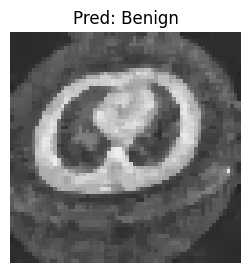

In [ ]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# --- pick model for inference ---
MODEL_NAME_FOR_PREDICT = "CNN_ViT"  # CNN_ViT recommended

model_for_predict = None
if MODEL_NAME_FOR_PREDICT == "CNN_ViT" and "model_vit" in globals():
    model_for_predict = globals()["model_vit"]

if model_for_predict is None:
    # try load saved model (optional)
    model_path = MODELS_DIR / "CNN_ViT.keras"
    if model_path.exists():
        import tensorflow as tf
        model_for_predict = tf.keras.models.load_model(model_path)
        print("Loaded model:", model_path)
    else:
        raise RuntimeError("No trained model found. Run Step 9 (CNN_ViT) first, or save a model at OUTPUT_ROOT/models/CNN_ViT.keras")

# --- upload / choose image ---
image_path = None
try:
    from google.colab import files  # type: ignore
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file uploaded")
    image_path = list(uploaded.keys())[0]
except Exception:
    # local: type a path
    image_path = input("Enter image path (local): ").strip()

p = Path(image_path)
if not p.exists():
    raise FileNotFoundError(f"Image not found: {p}")

# --- preprocess (same pipeline as training) ---
x = preprocess_image_np(str(p))  # (H,W,C) float32
x_in = np.expand_dims(x, axis=0)

# --- predict ---
prob = model_for_predict.predict(x_in, verbose=0)[0]
pred_id = int(np.argmax(prob))
pred_label = class_names[pred_id] if "class_names" in globals() else str(pred_id)

print("Predicted:", pred_label)
print("Probabilities:")
for i, pr in enumerate(prob):
    name = class_names[i] if "class_names" in globals() else str(i)
    print(f"  {name}: {float(pr):.4f}")

# show input
plt.figure(figsize=(3,3))
if x.shape[-1] == 1:
    plt.imshow(x[..., 0].clip(0, 1), cmap="gray")
else:
    plt.imshow(x.clip(0, 1))
plt.title(f"Pred: {pred_label}")
plt.axis("off")
plt.show()


Prediction For Hybrid 3 Model



In [ ]:
# --- Detect Colab ---
from __future__ import annotations

import json
import time
import shutil
from pathlib import Path

import numpy as np

try:
    from google.colab import files, drive  # type: ignore
    _IN_COLAB = True
except Exception:
    _IN_COLAB = False

# Reuse existing flag if present
IN_COLAB = bool(globals().get("IN_COLAB", _IN_COLAB))

# --- Save directory ---
if IN_COLAB:
    try:
        drive.mount('/content/drive', force_remount=False)
    except Exception:
        pass
    SAVE_DIR = Path("/content/drive/MyDrive/predictions")
else:
    SAVE_DIR = Path("processed") / "predictions"

SAVE_DIR.mkdir(parents=True, exist_ok=True)
print("IN_COLAB =", IN_COLAB)
print("SAVE_DIR =", SAVE_DIR)

# --- Get / build feature model for CNN+ViT hybrid ---
if "feat_model_vit" not in globals():
    if "model_vit" not in globals():
        raise RuntimeError(
            "`model_vit` not found. Run Step 9 (CNN_ViT) or load processed/models/cnn_vit.keras, then run the Hybrid cell."
        )

    import tensorflow as tf

    try:
        cnn_gap = model_vit.get_layer("cnn_gap").output
        vit_gap = model_vit.get_layer("vit_gap").output
    except Exception as e:
        raise RuntimeError(
            "Expected layers named 'cnn_gap' and 'vit_gap' in model_vit. Train with the provided CNN_ViT definition."
        ) from e

    hyb_feat = tf.keras.layers.Concatenate(name="cnn_vit_concat_feats")([cnn_gap, vit_gap])
    feat_model_vit = tf.keras.Model(model_vit.input, hyb_feat, name="cnn_vit_feature_model")

# --- Get classifier trained in Hybrid cell ---
clf = None
clf_name = None
if "xgb_clf" in globals():
    clf = globals()["xgb_clf"]
    clf_name = "xgboost.XGBClassifier"
elif "gbdt" in globals():
    clf = globals()["gbdt"]
    clf_name = "sklearn.HistGradientBoostingClassifier"

if clf is None:
    raise RuntimeError(
        "Hybrid classifier not found. Run the 'CNN + ViT + XGBoost' (Hybrid) training cell first so `xgb_clf` or `gbdt` exists."
    )

# --- Preprocess (match training as closely as possible) ---
IMG_SIZE = tuple(globals().get("IMG_SIZE", (64, 64)))
COLOR_MODE = str(globals().get("COLOR_MODE", "rgb"))
NORMALIZE_0_1 = bool(globals().get("NORMALIZE_0_1", True))
STANDARDIZE = bool(globals().get("STANDARDIZE", False))


def _preprocess_path_to_batch(path: Path) -> np.ndarray:
    if "preprocess_image_np" in globals():
        try:
            x = globals()["preprocess_image_np"](str(path))
            return np.expand_dims(x, axis=0).astype(np.float32)
        except Exception as e:
            print("preprocess_image_np failed -> fallback to PIL:", e)

    # Fallback (if OpenCV pipeline isn't available)
    try:
        from PIL import Image
    except Exception as e:
        raise RuntimeError("Neither preprocess_image_np nor PIL is available for preprocessing.") from e

    im = Image.open(path)
    if COLOR_MODE == "grayscale":
        im = im.convert("L")
    else:
        im = im.convert("RGB")

    im = im.resize((int(IMG_SIZE[1]), int(IMG_SIZE[0])))
    arr = np.asarray(im).astype(np.float32)
    if COLOR_MODE == "grayscale":
        arr = np.expand_dims(arr, axis=-1)

    if NORMALIZE_0_1:
        arr = arr / 255.0
    if STANDARDIZE:
        arr = (arr - float(arr.mean())) / float(arr.std() + 1e-6)

    return np.expand_dims(arr, axis=0)


def predict_and_save(image_path: Path):
    if not image_path.exists():
        raise FileNotFoundError(str(image_path))

    x = _preprocess_path_to_batch(image_path)
    feats = feat_model_vit.predict(x, verbose=0)

    # sklearn + xgboost both support predict_proba
    prob = clf.predict_proba(feats)[0]

    class_names = list(globals().get("class_names", []))
    pred_id = int(np.argmax(prob))
    pred_label = class_names[pred_id] if class_names and pred_id < len(class_names) else str(pred_id)

    ts = time.strftime("%Y%m%d-%H%M%S")
    stem = image_path.stem

    # Save JSON
    out_json = SAVE_DIR / f"{stem}__{ts}__pred.json"
    payload = {
        "timestamp": ts,
        "input_path": str(image_path),
        "model": "CNN+ViT feats -> XGBoost/GBDT",
        "classifier": clf_name,
        "pred_id": pred_id,
        "pred_label": pred_label,
        "prob": { (class_names[i] if i < len(class_names) else str(i)): float(prob[i]) for i in range(len(prob)) },
    }
    out_json.write_text(json.dumps(payload, indent=2), encoding="utf-8")

    # Save a copy of the image (label in filename)
    out_img = SAVE_DIR / f"{stem}__{ts}__pred-{pred_label}{image_path.suffix.lower()}"
    try:
        shutil.copy2(image_path, out_img)
    except Exception:
        # If suffix isn't a real file suffix (or copy fails), just write bytes
        out_img.write_bytes(image_path.read_bytes())

    print("pred_label:", pred_label)
    print("saved:", out_json)
    print("saved:", out_img)


# --- Upload/select image & run ---
if IN_COLAB:
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("No file uploaded")

    name, content = next(iter(uploaded.items()))
    tmp = SAVE_DIR / f"_upload_{int(time.time())}_{Path(name).name}"
    tmp.write_bytes(content)
    print("uploaded ->", tmp)
    predict_and_save(tmp)
else:
    # Option A: set image_path manually (works everywhere)
    image_path = globals().get("image_path", None)
    if image_path:
        predict_and_save(Path(str(image_path)))
    else:
        # Option B: local Jupyter upload widget (needs ipywidgets)
        try:
            import ipywidgets as widgets  # type: ignore
            from IPython.display import display

            uploader = widgets.FileUpload(accept='image/*', multiple=False)

            def _on_upload(change):
                if not uploader.value:
                    return
                name2, info = next(iter(uploader.value.items()))
                tmp2 = SAVE_DIR / f"_upload_{int(time.time())}_{Path(name2).name}"
                tmp2.write_bytes(info["content"])
                print("uploaded ->", tmp2)
                predict_and_save(tmp2)

            uploader.observe(_on_upload, names='value')
            display(uploader)
            print("Upload an image using the widget above...")
        except Exception as e:
            raise RuntimeError(
                "Not in Colab, and no `image_path` set. Either set `image_path = '.../img.jpg'` or install ipywidgets for upload widget."
            ) from e

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
IN_COLAB = True
SAVE_DIR = /content/drive/MyDrive/predictions


Saving 41_Benign (136).JPG to 41_Benign (136).JPG
uploaded -> /content/drive/MyDrive/predictions/_upload_1770637821_41_Benign (136).JPG
pred_label: Normal
saved: /content/drive/MyDrive/predictions/_upload_1770637821_41_Benign (136)__20260209-115021__pred.json
saved: /content/drive/MyDrive/predictions/_upload_1770637821_41_Benign (136)__20260209-115021__pred-Normal.jpg


Making Outputs On a Zip File

In [ ]:
# === (Optional) Export outputs ===
# This will create a zip of OUTPUT_ROOT so you can download or keep in Drive.

import shutil, os
zip_base = str(OUTPUT_ROOT)
zip_path = shutil.make_archive(zip_base, 'zip', root_dir=str(OUTPUT_ROOT))
print("Zipped outputs to:", zip_path)

# show saved files (top level)
for p in sorted(OUTPUT_ROOT.glob("*")):
    print("-", p.name)


Zipped outputs to: /content/drive/MyDrive/processed_outputs.zip
- metrics.json
- models
- mpl_cache
- plots
- splits
